# Probability Basics สำหรับ Machine Learning — เรียนด้วย NumPy ทีละขั้น

**ระดับ:** เริ่มต้น–ปานกลาง • **เวลาประมาณ:** 90–120 นาที แบ่งเรียนได้ 2–3 รอบ •
**ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้เป็น notebook แรกของ **Phase 02 — Statistics** ต่อจาก Phase 01 (คณิตศาสตร์/NumPy)
เนื้อหา โค้ด และตัวอย่างทั้งหมดสร้างขึ้นใหม่สำหรับ notebook นี้ เน้นความน่าจะเป็นเชิงทฤษฎีพื้นฐาน
(sample space, การนับ, conditional probability) — ยังไม่ลงรายละเอียดสถิติเชิงพรรณนา (mean/variance
จากข้อมูลจริง อยู่ใน `02_descriptive_statistics.ipynb`), การแจกแจงที่มีชื่อ (normal, binomial ฯลฯ
อยู่ใน `03_distributions.ipynb`) หรือ Bayes' theorem แบบเต็มรูป (อยู่ใน `04_bayes_theorem.ipynb`)

**ก่อนเริ่ม:** ไม่จำเป็นต้องมีพื้นฐานสถิติมาก่อน แต่ควรคุ้นเคยกับ NumPy array และ `rng.integers`/`rng.choice`
จาก Phase 01 เลือก kernel `.venv` ของโครงการ แล้วใช้ **Restart Kernel → Run All**

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. sample space, event และสัจพจน์ความน่าจะเป็น (probability axioms) คืออะไร
2. permutation กับ combination ต่างกันอย่างไร และใช้นับความน่าจะเป็นแบบ classical ได้อย่างไร
3. ทำไมความถี่จากการทดลองสุ่มจำนวนมากจึงเข้าใกล้ความน่าจะเป็นทางทฤษฎี (law of large numbers)
4. conditional probability และ independence ต่างกันอย่างไร และตรวจสอบได้อย่างไร
5. law of total probability คืออะไร และเป็นฐานของ Bayes' theorem อย่างไร
6. random variable แบบ discrete คืออะไร และหา $E[X]$, $\mathrm{Var}[X]$ จาก PMF ได้อย่างไร

**เส้นทาง:** ส่วน 1–3 พื้นฐานและการนับ → ส่วน 4 simulation/law of large numbers →
ส่วน 5–7 conditional probability, independence, law of total probability →
ส่วน 8 random variable → ส่วน 9 mini-project (Monty Hall) → ส่วน 10–11 สรุปและแบบฝึกหัด

## 1. เตรียมเครื่องมือ

ใช้ `math.comb`/`math.perm` (Python standard library) เป็นตัวเทียบกับฟังก์ชันนับที่เขียนเอง
และใช้ `numpy.random.Generator` สำหรับ Monte Carlo simulation ตลอดทั้ง notebook

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Sample Space, Event และสัจพจน์ความน่าจะเป็น

**Sample space** ($S$) คือเซตของผลลัพธ์ที่เป็นไปได้ทั้งหมดของการทดลองสุ่ม **Event** คือ subset ของ $S$
สัจพจน์ความน่าจะเป็น (Kolmogorov axioms):

$$P(S)=1, \qquad P(A)\ge 0 \text{ สำหรับทุก event } A, \qquad
P(A\cup B) = P(A)+P(B) \text{ ถ้า } A\cap B=\emptyset$$

**ตัวอย่าง:** ทอยลูกเต๋าหกหน้า $S=\{1,2,3,4,5,6\}$ ทุกผลลัพธ์มีโอกาสเท่ากัน (equally likely)
จึงนิยาม **classical probability** ได้ว่า $P(A)=|A|/|S|$

อ้างอิง: [Wikipedia — Probability axioms](https://en.wikipedia.org/wiki/Probability_axioms)

In [2]:
S = set(range(1, 7))
A_even = {2, 4, 6}
B_odd = {1, 3, 5}


def classical_probability(event, sample_space):
    return len(event) / len(sample_space)


print("P(S) =", classical_probability(S, S))
print("P(even) =", classical_probability(A_even, S))
print("P(odd) =", classical_probability(B_odd, S))
assert classical_probability(S, S) == 1.0
assert A_even.isdisjoint(B_odd)  # เซตทั้งสองไม่มีสมาชิกร่วมกัน (mutually exclusive)
assert classical_probability(A_even | B_odd, S) == classical_probability(
    A_even, S
) + classical_probability(B_odd, S)
print("ตรวจสัจพจน์ผ่าน: P(S)=1 และ P(A∪B)=P(A)+P(B) เมื่อ A, B แยกจากกัน")

P(S) = 1.0
P(even) = 0.5
P(odd) = 0.5
ตรวจสัจพจน์ผ่าน: P(S)=1 และ P(A∪B)=P(A)+P(B) เมื่อ A, B แยกจากกัน


## 3. การนับ: Permutation และ Combination

**Permutation** $nPr = \dfrac{n!}{(n-r)!}$ นับการจัดเรียงที่ **สนใจลำดับ**
**Combination** $nCr = \dbinom{n}{r} = \dfrac{n!}{r!(n-r)!}$ นับการเลือกที่ **ไม่สนใจลำดับ**

Python มี `math.perm` และ `math.comb` ให้ใช้ตรงๆ ไม่ต้องเขียนเองในงานจริง แต่บทเรียนนี้เขียนจาก
factorial ก่อน เพื่อให้เห็นที่มาของสูตร

**Use case — คำนวณ classical probability จากการนับ:** โถใส่ลูกบอลสีแดง 5 ลูก สีน้ำเงิน 3 ลูก
สุ่มหยิบ 3 ลูกพร้อมกัน (ไม่ใส่คืน) ความน่าจะเป็นที่จะได้สีแดงพอดี 2 ลูกคือเท่าไร?

อ้างอิง: [Wikipedia — Combination](https://en.wikipedia.org/wiki/Combination)

In [3]:
def factorial_manual(n):
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


def nPr_manual(n, r):
    return factorial_manual(n) // factorial_manual(n - r)


def nCr_manual(n, r):
    return factorial_manual(n) // (factorial_manual(r) * factorial_manual(n - r))


for n, r in [(6, 2), (8, 3), (5, 0), (10, 10)]:
    assert nPr_manual(n, r) == math.perm(n, r)
    assert nCr_manual(n, r) == math.comb(n, r)
print("nPr/nCr ที่เขียนเองตรงกับ math.perm/math.comb ทุกกรณีทดสอบ")

red, blue, draw = 5, 3, 3
total = red + blue
ways_2red_1blue = nCr_manual(red, 2) * nCr_manual(blue, 1)
ways_total = nCr_manual(total, draw)
p_exactly_2_red = ways_2red_1blue / ways_total
print(f"วิธีเลือก 2 แดง 1 น้ำเงิน: {ways_2red_1blue} วิธี, ทั้งหมด {ways_total} วิธี")
print(f"P(ได้สีแดงพอดี 2 ลูก) = {ways_2red_1blue}/{ways_total} = {p_exactly_2_red:.4f}")
assert math.isclose(p_exactly_2_red, 15 / 28)

nPr/nCr ที่เขียนเองตรงกับ math.perm/math.comb ทุกกรณีทดสอบ
วิธีเลือก 2 แดง 1 น้ำเงิน: 30 วิธี, ทั้งหมด 56 วิธี
P(ได้สีแดงพอดี 2 ลูก) = 30/56 = 0.5357


## 4. Law of Large Numbers: ทำไม Simulation ถึงใช้ตรวจคำตอบได้

**Law of large numbers** บอกว่า ถ้าทำการทดลองสุ่มซ้ำเป็นจำนวนมาก ความถี่สัมพัทธ์ (relative frequency)
ของ event จะเข้าใกล้ค่าความน่าจะเป็นทางทฤษฎี นี่คือเหตุผลที่ตลอด notebook นี้ใช้ Monte Carlo
simulation ตรวจคำตอบที่คำนวณด้วยมือได้ — **ไม่ใช่การพิสูจน์ทางคณิตศาสตร์ แต่เป็นหลักฐานเชิงประจักษ์**

อ้างอิง: [Wikipedia — Law of large numbers](https://en.wikipedia.org/wiki/Law_of_large_numbers)

N=       10: P(even) โดยประมาณ = 0.3000
N=      100: P(even) โดยประมาณ = 0.3700
N=    1,000: P(even) โดยประมาณ = 0.4930
N=   10,000: P(even) โดยประมาณ = 0.5053
N=  100,000: P(even) โดยประมาณ = 0.4994
N=1,000,000: P(even) โดยประมาณ = 0.5004


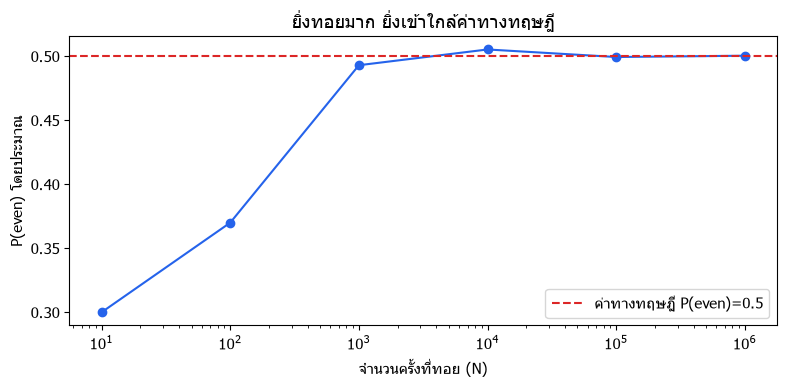

In [4]:
rng = np.random.default_rng(SEED)
sample_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
empirical_p_even = []
for n_trials in sample_sizes:
    rolls = rng.integers(1, 7, size=n_trials)
    empirical_p_even.append(np.mean(rolls % 2 == 0))

for n_trials, p_hat in zip(sample_sizes, empirical_p_even):
    print(f"N={n_trials:>9,}: P(even) โดยประมาณ = {p_hat:.4f}")
assert abs(empirical_p_even[-1] - 0.5) < 0.01

fig, ax = plt.subplots()
ax.semilogx(sample_sizes, empirical_p_even, "o-", color="#2563eb")
ax.axhline(
    0.5, linestyle="--", color="#dc2626", label=label("ค่าทางทฤษฎี P(even)=0.5", "theoretical 0.5")
)
ax.set_xlabel(label("จำนวนครั้งที่ทอย (N)", "Number of trials (N)"))
ax.set_ylabel("P(even) โดยประมาณ")
ax.legend()
ax.set_title(label("ยิ่งทอยมาก ยิ่งเข้าใกล้ค่าทางทฤษฎี", "More trials converge to the theoretical value"))
plt.tight_layout()
plt.show()

In [5]:
def simulate_urn_draw(rng, n_trials, red, blue, draw):
    urn = np.array([1] * red + [0] * blue)  # 1 = แดง, 0 = น้ำเงิน
    counts_red = np.empty(n_trials, dtype=int)
    for i in range(n_trials):
        drawn = rng.choice(urn, size=draw, replace=False)
        counts_red[i] = drawn.sum()
    return counts_red


rng = np.random.default_rng(SEED)
n_sim = 200_000
counts_red = simulate_urn_draw(rng, n_sim, red, blue, draw)
empirical_p_2red = np.mean(counts_red == 2)
print(f"P(ได้สีแดงพอดี 2 ลูก) จากการนับ (ส่วน 3): {p_exactly_2_red:.4f}")
print(f"P(ได้สีแดงพอดี 2 ลูก) จาก simulation {n_sim:,} รอบ: {empirical_p_2red:.4f}")
np.testing.assert_allclose(empirical_p_2red, p_exactly_2_red, atol=0.01)
print("การนับด้วยมือกับ simulation ให้ผลตรงกัน (ในขอบเขตความคลาดเคลื่อนของการสุ่ม)")

P(ได้สีแดงพอดี 2 ลูก) จากการนับ (ส่วน 3): 0.5357
P(ได้สีแดงพอดี 2 ลูก) จาก simulation 200,000 รอบ: 0.5352
การนับด้วยมือกับ simulation ให้ผลตรงกัน (ในขอบเขตความคลาดเคลื่อนของการสุ่ม)


## 5. Conditional Probability

$$P(A\mid B) = \frac{P(A\cap B)}{P(B)}, \qquad P(B) > 0$$

อ่านว่า "ความน่าจะเป็นของ $A$ **เมื่อรู้แล้วว่า** $B$ เกิดขึ้น" — ข้อมูลใหม่ (เงื่อนไข $B$)
ทำให้ sample space ที่สนใจแคบลงเหลือเฉพาะส่วนที่ $B$ เป็นจริง

**ตัวอย่าง 1 (ลูกเต๋า):** $P(\text{ได้เลข }4 \mid \text{เลขคู่}) = \dfrac{P(\{4\})}{P(\{2,4,6\})}
= \dfrac{1/6}{3/6}=\dfrac13$

**ตัวอย่าง 2 (โถลูกบอล ไม่ใส่คืน):** หยิบทีละลูก 2 ครั้ง $P(\text{ลูกที่ 2 เป็นสีแดง} \mid
\text{ลูกที่ 1 เป็นสีแดง})$ — หลังหยิบลูกแดงออกไปแล้ว 1 ลูก เหลือแดง 4 จากทั้งหมด 7 ลูก

In [6]:
p_4_given_even = (1 / 6) / (3 / 6)
print("P(4 | เลขคู่) ทางทฤษฎี:", p_4_given_even)

rng = np.random.default_rng(SEED)
rolls = rng.integers(1, 7, size=1_000_000)
even_rolls = rolls[rolls % 2 == 0]
empirical_p_4_given_even = np.mean(even_rolls == 4)
print("P(4 | เลขคู่) จาก simulation:", empirical_p_4_given_even)
np.testing.assert_allclose(empirical_p_4_given_even, p_4_given_even, atol=0.01)

p_first_red = red / total
p_both_red = nCr_manual(red, 2) / nCr_manual(total, 2)
p_second_red_given_first_red = p_both_red / p_first_red
print(f"P(ลูกที่ 2 แดง | ลูกที่ 1 แดง) ทางทฤษฎี = {p_second_red_given_first_red:.4f} (ควรเท่ากับ 4/7)")
assert math.isclose(p_second_red_given_first_red, 4 / 7)

rng = np.random.default_rng(SEED)
urn = np.array([1] * red + [0] * blue)
n_sim2 = 300_000
first_draws = np.empty(n_sim2, dtype=int)
second_draws = np.empty(n_sim2, dtype=int)
for i in range(n_sim2):
    drawn = rng.choice(urn, size=2, replace=False)
    first_draws[i], second_draws[i] = drawn[0], drawn[1]

mask_first_red = first_draws == 1
empirical_cond = np.mean(second_draws[mask_first_red] == 1)
print("P(ลูกที่ 2 แดง | ลูกที่ 1 แดง) จาก simulation:", empirical_cond)
np.testing.assert_allclose(empirical_cond, p_second_red_given_first_red, atol=0.02)

P(4 | เลขคู่) ทางทฤษฎี: 0.3333333333333333
P(4 | เลขคู่) จาก simulation: 0.33423831553357297
P(ลูกที่ 2 แดง | ลูกที่ 1 แดง) ทางทฤษฎี = 0.5714 (ควรเท่ากับ 4/7)


P(ลูกที่ 2 แดง | ลูกที่ 1 แดง) จาก simulation: 0.5701954892025384


## 6. Independence: เมื่อเงื่อนไขไม่ส่งผล

event $A$ และ $B$ **เป็นอิสระต่อกัน (independent)** ก็ต่อเมื่อ $P(A\cap B)=P(A)P(B)$
เทียบเท่ากับ $P(A\mid B)=P(A)$ — รู้ว่า $B$ เกิดขึ้นไม่ได้ให้ข้อมูลอะไรเพิ่มเกี่ยวกับ $A$

- **ทอยลูกเต๋าสองลูกแยกกัน:** independent — ผลของลูกแรกไม่ส่งผลต่อลูกที่สอง
- **หยิบลูกบอลจากโถแบบไม่ใส่คืน:** **dependent** — ผลของการหยิบครั้งแรกเปลี่ยนสัดส่วนในโถสำหรับครั้งถัดไป

In [7]:
rng = np.random.default_rng(SEED)
n_sim3 = 500_000
die1 = rng.integers(1, 7, size=n_sim3)
die2 = rng.integers(1, 7, size=n_sim3)
p_both_even_indep = np.mean((die1 % 2 == 0) & (die2 % 2 == 0))
p_each_even = 0.5 * 0.5
print(f"ลูกเต๋าสองลูกแยกกัน: P(ทั้งคู่คู่) จำลอง = {p_both_even_indep:.4f}, P(A)P(B) = {p_each_even:.4f}")
np.testing.assert_allclose(p_both_even_indep, p_each_even, atol=0.01)
print("ใกล้เคียงกันมาก → สอดคล้องกับ independence")

# หาความน่าจะเป็น "เพียงอย่างเดียว" (marginal) ของลูกที่ 2 เป็นสีแดง โดยไม่ยึดเงื่อนไขลูกแรก
p_second_red_marginal = p_first_red * (4 / 7) + (blue / total) * (red / (total - 1))
print(f"P(ลูกที่ 2 แดง) แบบไม่มีเงื่อนไข = {p_second_red_marginal:.4f} (ควรเท่ากับ 5/8 = 0.625)")
assert math.isclose(p_second_red_marginal, 5 / 8)

p_both_red_if_independent = p_first_red * p_second_red_marginal
print(
    f"P(ทั้งคู่แดง) จริง = {p_both_red:.4f}, ถ้าสมมติว่า independent (ผิด) จะได้ = {p_both_red_if_independent:.4f}"
)
assert not math.isclose(p_both_red, p_both_red_if_independent, abs_tol=1e-9)
print("สองค่านี้ไม่เท่ากัน → ยืนยันว่าการหยิบแบบไม่ใส่คืนไม่ใช่ independent event")

ลูกเต๋าสองลูกแยกกัน: P(ทั้งคู่คู่) จำลอง = 0.2501, P(A)P(B) = 0.2500
ใกล้เคียงกันมาก → สอดคล้องกับ independence
P(ลูกที่ 2 แดง) แบบไม่มีเงื่อนไข = 0.6250 (ควรเท่ากับ 5/8 = 0.625)
P(ทั้งคู่แดง) จริง = 0.3571, ถ้าสมมติว่า independent (ผิด) จะได้ = 0.3906
สองค่านี้ไม่เท่ากัน → ยืนยันว่าการหยิบแบบไม่ใส่คืนไม่ใช่ independent event


## 7. Law of Total Probability

ถ้า $B_1,\dots,B_k$ แบ่ง sample space ออกเป็นส่วนที่ไม่ทับกันและครอบคลุมทั้งหมด (**partition**):

$$P(A) = \sum_{i=1}^{k} P(A\mid B_i)\,P(B_i)$$

**ตัวอย่าง:** มีกล่อง 3 ใบ สุ่มเลือกกล่องด้วยความน่าจะเป็น $P(\text{กล่อง }i)$ ที่กำหนดไว้ แต่ละกล่องมีสัดส่วน
ลูกบอลสีแดงต่างกัน $P(\text{แดง}\mid\text{กล่อง }i)$ แล้วสุ่มหยิบลูกบอลจากกล่องที่เลือก
ความน่าจะเป็นที่จะได้สีแดง**โดยไม่รู้ว่าเลือกกล่องไหน**คือเท่าไร?

**นี่คือฐานของ Bayes' theorem:** ถ้าอยากรู้กลับกัน — "หยิบได้สีแดงแล้ว กล่องไหนน่าจะเป็นกล่องที่เลือก?" —
นั่นคือ $P(B_i\mid A)$ ซึ่งเป็นหัวข้อของ `04_bayes_theorem.ipynb`

อ้างอิง: [Wikipedia — Law of total probability](https://en.wikipedia.org/wiki/Law_of_total_probability)

In [8]:
p_box = np.array([0.5, 0.3, 0.2])  # P(กล่อง 1), P(กล่อง 2), P(กล่อง 3)
p_red_given_box = np.array([0.3, 0.6, 0.9])  # สัดส่วนสีแดงในแต่ละกล่อง
assert math.isclose(p_box.sum(), 1.0)

p_red_total = np.sum(p_box * p_red_given_box)
print("P(กล่อง):", p_box, "; P(แดง | กล่อง):", p_red_given_box)
print(f"P(แดง) = Σ P(แดง|กล่อง_i) P(กล่อง_i) = {p_red_total:.4f}")
assert math.isclose(p_red_total, 0.51)

rng = np.random.default_rng(SEED)
n_sim4 = 300_000
box_choice = rng.choice(3, size=n_sim4, p=p_box)
draws_red = np.array([rng.random() < p_red_given_box[b] for b in box_choice])
empirical_p_red = draws_red.mean()
print(f"P(แดง) จาก simulation {n_sim4:,} รอบ: {empirical_p_red:.4f}")
np.testing.assert_allclose(empirical_p_red, p_red_total, atol=0.01)

P(กล่อง): [0.5 0.3 0.2] ; P(แดง | กล่อง): [0.3 0.6 0.9]
P(แดง) = Σ P(แดง|กล่อง_i) P(กล่อง_i) = 0.5100
P(แดง) จาก simulation 300,000 รอบ: 0.5101


## 8. Random Variable เบื้องต้น: Discrete vs Continuous

**Random variable** ($X$) คือฟังก์ชันที่แปลงผลลัพธ์ของการทดลองสุ่มให้เป็นตัวเลข
**Discrete random variable** มีค่าที่เป็นไปได้นับได้ (เช่น ผลทอยลูกเต๋า) อธิบายด้วย
**probability mass function (PMF)**: $P(X=k)$ **Continuous random variable** มีค่าต่อเนื่อง
(เช่น ส่วนสูง) ต้องใช้ **probability density function (PDF)** แทน — รายละเอียดเต็มอยู่ใน
`03_distributions.ipynb`

จาก PMF คำนวณค่าคาดหวัง (expected value) และความแปรปรวน (variance) **ทางทฤษฎี** ได้โดยตรง
(ต่างจาก sample mean/variance จากข้อมูลจริงใน `02_descriptive_statistics.ipynb`):

$$E[X]=\sum_k k\,P(X=k), \qquad \mathrm{Var}[X]=E[X^2]-\big(E[X]\big)^2$$

In [9]:
outcomes = np.arange(1, 7)
pmf = np.full(6, 1 / 6)  # ลูกเต๋าเที่ยงตรง ทุกหน้ามีโอกาสเท่ากัน
assert math.isclose(pmf.sum(), 1.0)

E_X = np.sum(outcomes * pmf)
E_X2 = np.sum(outcomes**2 * pmf)
Var_X = E_X2 - E_X**2
print(f"E[X] = {E_X:.4f} (ทฤษฎี: 21/6 = 3.5)")
print(f"Var[X] = {Var_X:.4f} (ทฤษฎี: 35/12 ≈ 2.9167)")
assert math.isclose(E_X, 3.5)
assert math.isclose(Var_X, 35 / 12)

rng = np.random.default_rng(SEED)
rolls = rng.integers(1, 7, size=1_000_000)
print(f"ค่าเฉลี่ยจาก simulation: {rolls.mean():.4f}, ความแปรปรวนจาก simulation: {rolls.var():.4f}")
np.testing.assert_allclose(rolls.mean(), E_X, atol=0.01)
np.testing.assert_allclose(rolls.var(), Var_X, atol=0.02)
print("ค่าเฉลี่ย/ความแปรปรวนจาก simulation ใกล้เคียงค่าทางทฤษฎีที่คำนวณจาก PMF")

E[X] = 3.5000 (ทฤษฎี: 21/6 = 3.5)
Var[X] = 2.9167 (ทฤษฎี: 35/12 ≈ 2.9167)
ค่าเฉลี่ยจาก simulation: 3.4981, ความแปรปรวนจาก simulation: 2.9152
ค่าเฉลี่ย/ความแปรปรวนจาก simulation ใกล้เคียงค่าทางทฤษฎีที่คำนวณจาก PMF


## 9. Mini-project: จำลองปัญหา Monty Hall

มีประตู 3 บาน หลังบานหนึ่งมีรถยนต์ (รางวัล) อีกสองบานมีแพะ ผู้เข้าแข่งขันเลือกประตูหนึ่งบาน
จากนั้นพิธีกร (**รู้ว่ารถอยู่หลังบานไหน**) เปิดประตูอีกบานที่มีแพะออกให้ดู แล้วถามว่า
"จะเปลี่ยนใจไปเลือกอีกบานที่เหลือไหม?"

สัญชาตญาณส่วนใหญ่บอกว่า "เปลี่ยนหรือไม่เปลี่ยนก็ 50/50" แต่ในทางทฤษฎี **การเปลี่ยนใจ (switch)
มีโอกาสชนะสูงกว่าการอยู่กับที่เดิม (stay) ถึงสองเท่า** ($2/3$ เทียบกับ $1/3$) จำลองเกมนี้หลายหมื่นรอบ
เพื่อตรวจสอบ

อ้างอิง: [Wikipedia — Monty Hall problem](https://en.wikipedia.org/wiki/Monty_Hall_problem)

P(ชนะถ้า stay) จาก simulation 100,000 รอบ: 0.3312 (ทฤษฎี: 1/3 ≈ 0.3333)
P(ชนะถ้า switch) จาก simulation: 0.6688 (ทฤษฎี: 2/3 ≈ 0.6667)


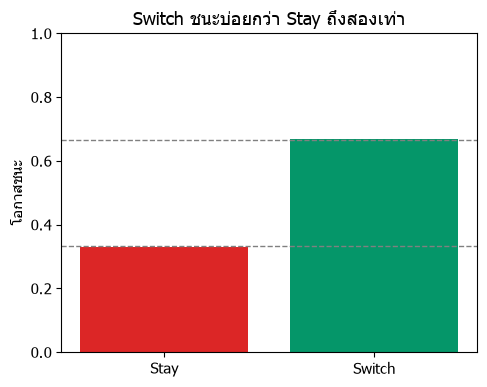

In [10]:
def simulate_monty_hall(rng, n_trials):
    car_door = rng.integers(0, 3, size=n_trials)
    initial_pick = rng.integers(0, 3, size=n_trials)
    host_reveal = np.empty(n_trials, dtype=int)
    switch_pick = np.empty(n_trials, dtype=int)
    doors = [0, 1, 2]

    for i in range(n_trials):
        p, c = initial_pick[i], car_door[i]
        if p == c:
            # ผู้เข้าแข่งขันเลือกถูกตั้งแต่แรก พิธีกรเลือกเปิดแพะบานใดบานหนึ่งจากสองบานที่เหลือแบบสุ่ม
            goat_doors = [d for d in doors if d != p]
            host_reveal[i] = rng.choice(goat_doors)
        else:
            # ผู้เข้าแข่งขันเลือกผิด พิธีกรถูกบังคับให้เปิดประตูแพะบานที่เหลือเพียงบานเดียว
            host_reveal[i] = next(d for d in doors if d != p and d != c)
        switch_pick[i] = next(d for d in doors if d != p and d != host_reveal[i])

    return car_door, initial_pick, switch_pick


rng = np.random.default_rng(SEED)
n_trials = 100_000
car_door, initial_pick, switch_pick = simulate_monty_hall(rng, n_trials)

stay_wins = initial_pick == car_door
switch_wins = switch_pick == car_door
assert np.all(stay_wins != switch_wins)  # แต่ละรอบมีผู้ชนะแค่กลยุทธ์เดียวเสมอ

p_stay = stay_wins.mean()
p_switch = switch_wins.mean()
print(f"P(ชนะถ้า stay) จาก simulation {n_trials:,} รอบ: {p_stay:.4f} (ทฤษฎี: 1/3 ≈ 0.3333)")
print(f"P(ชนะถ้า switch) จาก simulation: {p_switch:.4f} (ทฤษฎี: 2/3 ≈ 0.6667)")
np.testing.assert_allclose(p_stay, 1 / 3, atol=0.01)
np.testing.assert_allclose(p_switch, 2 / 3, atol=0.01)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Stay", "Switch"], [p_stay, p_switch], color=["#dc2626", "#059669"])
ax.axhline(1 / 3, linestyle="--", color="gray", linewidth=1)
ax.axhline(2 / 3, linestyle="--", color="gray", linewidth=1)
ax.set_ylabel(label("โอกาสชนะ", "Win probability"))
ax.set_ylim(0, 1)
ax.set_title(label("Switch ชนะบ่อยกว่า Stay ถึงสองเท่า", "Switching wins twice as often as staying"))
plt.tight_layout()
plt.show()

## 10. แผนที่เชื่อมแนวคิดกับงานจริง

| แนวคิด | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|
| Sample space / axioms | `len(event)/len(S)` | นิยาม classical probability |
| Permutation / combination | `math.perm`, `math.comb` | นับความน่าจะเป็นเมื่อผลลัพธ์เท่ากันหมด |
| Law of large numbers | `rng.integers`, ค่าเฉลี่ยเมื่อ N มาก | ยืนยันสูตรทางทฤษฎีด้วย simulation |
| Conditional probability | `P(A∩B)/P(B)` | ปรับความเชื่อเมื่อมีข้อมูลใหม่ |
| Independence | `P(A∩B) == P(A)P(B)` | ตรวจว่าตัวแปรสองตัวเกี่ยวข้องกันหรือไม่ |
| Law of total probability | `Σ P(A\|Bᵢ)P(Bᵢ)` | ฐานของ Bayes' theorem (notebook ถัดไป) |
| Random variable (PMF) | `Σ k·P(X=k)` | ค่าคาดหวัง/ความแปรปรวนทางทฤษฎี |

**ก่อนสรุปผลจากความน่าจะเป็นทุกครั้ง:** ผลลัพธ์ทุกตัวมีโอกาสเท่ากันจริงหรือไม่ (ถ้าไม่ใช่
classical probability ใช้ไม่ได้)? เหตุการณ์ที่สนใจ independent หรือ dependent? ลองจำลองด้วย
simulation เพื่อตรวจคำตอบแล้วหรือยัง?

## 11. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. คำนวณ $P(\text{เลขน้อยกว่า }3 \mid \text{เลขคี่})$ สำหรับลูกเต๋าหกหน้า ด้วยมือ แล้วตรวจด้วย simulation
2. เปลี่ยนโถในส่วน 3–4 เป็นสีแดง 4 ลูก สีน้ำเงิน 6 ลูก สุ่มหยิบ 2 ลูก คำนวณ
   $P(\text{ได้สีแดงทั้งคู่})$ ด้วย `nCr_manual` แล้วตรวจด้วย simulation
3. ในส่วน 7 เปลี่ยน `p_box` เป็น `[0.2, 0.5, 0.3]` (ยังรวมกันได้ 1) แล้วคำนวณ `P(แดง)` ใหม่
4. ปรับ `simulate_monty_hall` ให้รองรับประตู **5 บาน** (รถ 1 บาน แพะ 4 บาน พิธีกรเปิดแพะทีละบาน
   จนเหลือ 2 บานให้เลือก) แล้วดูว่า switch ยังได้เปรียบไหม และได้เปรียบเท่าเดิมหรือมากกว่าเดิม
5. ใช้ PMF ของลูกเต๋าในส่วน 8 คำนวณ $E[X^2]$ ด้วยมือ แล้วเทียบกับ `E_X2` ในโค้ด

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [11]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
p_less_than_3_given_odd_exercise = None
print("ลองคำนวณ P(เลขน้อยกว่า 3 | เลขคี่) ด้วยมือก่อน แล้วค่อยตรวจด้วย simulation")

ลองคำนวณ P(เลขน้อยกว่า 3 | เลขคี่) ด้วยมือก่อน แล้วค่อยตรวจด้วย simulation


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
# ข้อ 1
less_than_3 = {1, 2}
odd = {1, 3, 5}
p_less_than_3_given_odd = len(less_than_3 & odd) / len(odd)
print("P(น้อยกว่า 3 | คี่) ทฤษฎี:", p_less_than_3_given_odd)  # {1}/{1,3,5} = 1/3

rng_exercise = np.random.default_rng(SEED)
rolls_exercise = rng_exercise.integers(1, 7, size=1_000_000)
odd_rolls_exercise = rolls_exercise[rolls_exercise % 2 == 1]
empirical_exercise = np.mean(odd_rolls_exercise < 3)
print("P(น้อยกว่า 3 | คี่) simulation:", empirical_exercise)
np.testing.assert_allclose(empirical_exercise, p_less_than_3_given_odd, atol=0.01)

# ข้อ 2
red2, blue2 = 4, 6
p_both_red_new = nCr_manual(red2, 2) / nCr_manual(red2 + blue2, 2)
print("P(ได้สีแดงทั้งคู่) ทฤษฎี:", p_both_red_new)

rng_exercise2 = np.random.default_rng(SEED)
urn_new = np.array([1] * red2 + [0] * blue2)
n_sim_exercise = 200_000
counts_exercise = np.empty(n_sim_exercise, dtype=int)
for i in range(n_sim_exercise):
    drawn = rng_exercise2.choice(urn_new, size=2, replace=False)
    counts_exercise[i] = drawn.sum()
empirical_new = np.mean(counts_exercise == 2)
print("P(ได้สีแดงทั้งคู่) simulation:", empirical_new)
np.testing.assert_allclose(empirical_new, p_both_red_new, atol=0.01)

# ข้อ 3
p_box_exercise = np.array([0.2, 0.5, 0.3])
p_red_total_exercise = np.sum(p_box_exercise * p_red_given_box)
print("P(แดง) เมื่อเปลี่ยน p_box:", p_red_total_exercise)

# ข้อ 4
def simulate_monty_hall_5doors(rng, n_trials):
    car_door = rng.integers(0, 5, size=n_trials)
    initial_pick = rng.integers(0, 5, size=n_trials)
    switch_wins_count = 0
    stay_wins_count = 0
    for i in range(n_trials):
        p, c = initial_pick[i], car_door[i]
        remaining = [d for d in range(5) if d != p]
        # พิธีกรเปิดแพะทีละบานจนเหลือ 1 บาน (ไม่เปิดบานที่เลือกไว้ และไม่เปิดบานที่มีรถ)
        goat_doors_to_keep_closed = [d for d in remaining if d == c] or [rng.choice(remaining)]
        final_switch_choice = goat_doors_to_keep_closed[0]
        if p == c:
            stay_wins_count += 1
        elif final_switch_choice == c:
            switch_wins_count += 1
    print("P(switch ชนะ) แบบ 5 ประตู:", switch_wins_count / n_trials)
    print("P(stay ชนะ) แบบ 5 ประตู:", stay_wins_count / n_trials)


simulate_monty_hall_5doors(np.random.default_rng(SEED), 20_000)
# switch ยังได้เปรียบกว่า stay (1/5) แต่ข้อได้เปรียบสัมพัทธ์ต่างจากกรณี 3 ประตู

# ข้อ 5
E_X2_manual = sum(k**2 * (1 / 6) for k in range(1, 7))
print("E[X^2] คำนวณด้วยมือ:", E_X2_manual)
np.testing.assert_allclose(E_X2_manual, E_X2)
```

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่าทำไม Monty Hall ควร switch เสมอ ฉันจะอธิบายด้วยภาษาของตัวเองว่า…
- conditional probability กับ independence ต่างกันอย่างไร ฉันจะยกตัวอย่างประกอบว่า…
- ก่อนสรุปผลจาก simulation ครั้งต่อไป ฉันจะตรวจสอบอะไรก่อนเชื่อผลลัพธ์…
- สิ่งที่ฉันยังไม่มั่นใจเกี่ยวกับบทนี้และอยากทบทวนเพิ่มคือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ตัวอย่าง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้คัดลอกข้อความจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **18 กันยายน 2026**

แหล่งอ้างอิง:

1. [Wikipedia — Probability axioms](https://en.wikipedia.org/wiki/Probability_axioms)
   ใช้เป็นจุดเริ่มต้นสำหรับสัจพจน์ Kolmogorov
2. [Wikipedia — Law of total probability](https://en.wikipedia.org/wiki/Law_of_total_probability)
   ใช้เป็นจุดเริ่มต้นสำหรับสูตรและการตีความว่าเป็นฐานของ Bayes' theorem
3. [Wikipedia — Monty Hall problem](https://en.wikipedia.org/wiki/Monty_Hall_problem)
   ใช้เป็นจุดเริ่มต้นสำหรับกติกาเกม; บทเรียนนี้เขียน simulation และการตรวจสอบเชิงตัวเลขขึ้นเอง

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [Python docs — math.comb](https://docs.python.org/3/library/math.html#math.comb)
- [Python docs — math.perm](https://docs.python.org/3/library/math.html#math.perm)
- [NumPy — random.Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)

อ่านต่อในโครงการ: `02_descriptive_statistics.ipynb` สำหรับสถิติเชิงพรรณนาจากข้อมูลจริง,
`03_distributions.ipynb` สำหรับการแจกแจงที่มีชื่อและ PDF/CDF, และ `04_bayes_theorem.ipynb`
สำหรับการต่อยอด law of total probability ในส่วน 7 ไปสู่ Bayes' theorem แบบเต็มรูป